# Phase 1: Data Preprocessing & Preparation

## Purpose
This notebook implements the complete data preprocessing pipeline for the thesis: *"Reliability and Interpretability of Uncertainty Estimation in Bus Travel Time Prediction under Temporal Distribution Shifts"*. Starting from the raw segment-level Astana bus transit dataset (~786K records, 55 days), we systematically clean, filter, and transform the data into analysis-ready datasets.

### Preprocessing Steps
1. **Remove exact duplicate records** that arise from data collection redundancy
2. **Remove anomalous dates** (Sep 3-4, 2024) where data collection failures produced insufficient records
3. **Remove outliers** using the IQR method applied per segment and direction to account for spatial heterogeneity
4. **Filter incomplete trips** that lack sufficient segment coverage for meaningful route-level aggregation
5. **Compute segment travel times** as the sum of run time and dwell time
6. **Aggregate to route-level** by summing segment times within each trip
7. **Join with GTFS** reference data to attach route identifiers
8. **Establish the temporal split strategy** (Train W1-W3, Calibration W4, Test-Near W5, Test-Mid W6, Test-Far W7-W8) that underpins all three experiments

### Thesis Connection
Each preprocessing decision directly impacts the experimental validity:
- **RQ1 (Distribution Shift):** The temporal split strategy creates progressively distant test periods to measure how conformal prediction coverage degrades over time.
- **RQ2 (Online vs Static):** Clean, consistent data across all periods ensures that observed coverage differences between static and online conformal methods reflect genuine methodological advantages rather than data artifacts.
- **RQ3 (Segment Decomposition):** Per-segment outlier removal and trip completeness filtering ensure that segment-level uncertainty estimates are meaningful and aggregable to the route level.

In [1]:
# === Imports & Setup ===
import sys
import os
import json
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))

from utils.data_loading import (
    load_segment_data, load_gtfs_trips, load_gtfs_routes,
    join_segment_with_gtfs
)
from utils.preprocessing import (
    remove_duplicate_records, detect_and_remove_outliers,
    filter_incomplete_trips, filter_anomalous_dates,
    compute_segment_travel_time, aggregate_to_route_level
)
from utils.temporal_splits import (
    get_temporal_split_by_period, label_temporal_period,
    WEEK_BOUNDARIES
)
from utils.visualization import set_thesis_style

# Apply thesis-quality plotting style
set_thesis_style()

# Paths
DATA_DIR = '../'
GTFS_DIR = '../data/gtfs_data/'
FIG_DIR = '../outputs/figures/phase1/'
TABLE_DIR = '../outputs/tables/'
PROCESSED_DIR = '../outputs/processed_data/'

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


---
## 1. Load Raw Data & Join with GTFS

We load the raw segment-level dataset and join it with GTFS trip and route reference data to attach route identifiers (`route_short_name`: 10, 12, 46) to every segment record. This join is essential because the raw segment data contains only `trip_id`, not the route identity.

In [2]:
# Load raw segment data
segment_df = load_segment_data(os.path.join(DATA_DIR, 'segment_level_data.csv'))

# Load GTFS reference data
trips_df = load_gtfs_trips(GTFS_DIR)
routes_df = load_gtfs_routes(GTFS_DIR)

# Join segment data with GTFS to add route information
df = join_segment_with_gtfs(segment_df, trips_df, routes_df)

print(f"Raw dataset shape: {df.shape}")
print(f"Date range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print(f"Number of unique dates: {df['date'].nunique()}")
print(f"Number of unique trips: {df['trip_id'].nunique():,}")
print(f"\nRoutes: {sorted(df['route_short_name'].dropna().unique())}")
print(f"\nRoute distribution:")
print(df['route_short_name'].value_counts())

Raw dataset shape: (785976, 18)
Date range: 2024-07-29 to 2024-09-21
Number of unique dates: 55
Number of unique trips: 19,769

Routes: [np.int64(10), np.int64(12), np.int64(46)]

Route distribution:
route_short_name
46    335078
10    243243
12    207655
Name: count, dtype: int64


---
## 2. Remove Duplicate Records

Exact duplicate rows can arise from data collection system retransmissions or database replication artifacts. We remove them to prevent inflating sample sizes and biasing summary statistics.

In [3]:
n_before_dedup = len(df)
df = remove_duplicate_records(df)
n_after_dedup = len(df)

print(f"\nBefore: {n_before_dedup:,} records")
print(f"After:  {n_after_dedup:,} records")
print(f"Removed: {n_before_dedup - n_after_dedup:,} duplicates")

Removed 0 duplicate records (0.00%)

Before: 785,976 records
After:  785,976 records
Removed: 0 duplicates


---
## 3. Remove Anomalous Dates (September 3-4, 2024)

Exploratory analysis in Phase 0 identified two dates with anomalously low record counts:
- **September 3, 2024**: Only **3,146 records** (vs. typical 10,000-18,000 per day)
- **September 4, 2024**: Only **111 records**

These volumes represent a **data collection failure** rather than genuine service disruption, as:
1. No public holidays or known service changes occurred on these dates
2. The drop is too extreme to reflect natural variation (>95% reduction)
3. The pattern is inconsistent with the rest of Week 6

Including these dates would bias Week 6 (test_mid) statistics and produce misleading conformal prediction coverage estimates. We apply a minimum threshold of 5,000 records per day.

In [4]:
n_before_anomalous = len(df)
df = filter_anomalous_dates(df, min_daily_records=5000)
n_after_anomalous = len(df)

print(f"\nBefore: {n_before_anomalous:,} records")
print(f"After:  {n_after_anomalous:,} records")
print(f"Removed: {n_before_anomalous - n_after_anomalous:,} records from anomalous dates")
print(f"Remaining unique dates: {df['date'].nunique()}")

Removing anomalous dates: ['2024-09-03', '2024-09-04'] (< 5,000 records each)
Removed 3,257 records from 2 anomalous dates

Before: 785,976 records
After:  782,719 records
Removed: 3,257 records from anomalous dates
Remaining unique dates: 53


---
## Plot P1.1: Pre-Cleaning Run Time Distribution

Before applying outlier removal, we visualize the current distribution of segment run times to understand the extent and nature of outliers. This serves as the "before" baseline for comparison after IQR-based outlier removal.

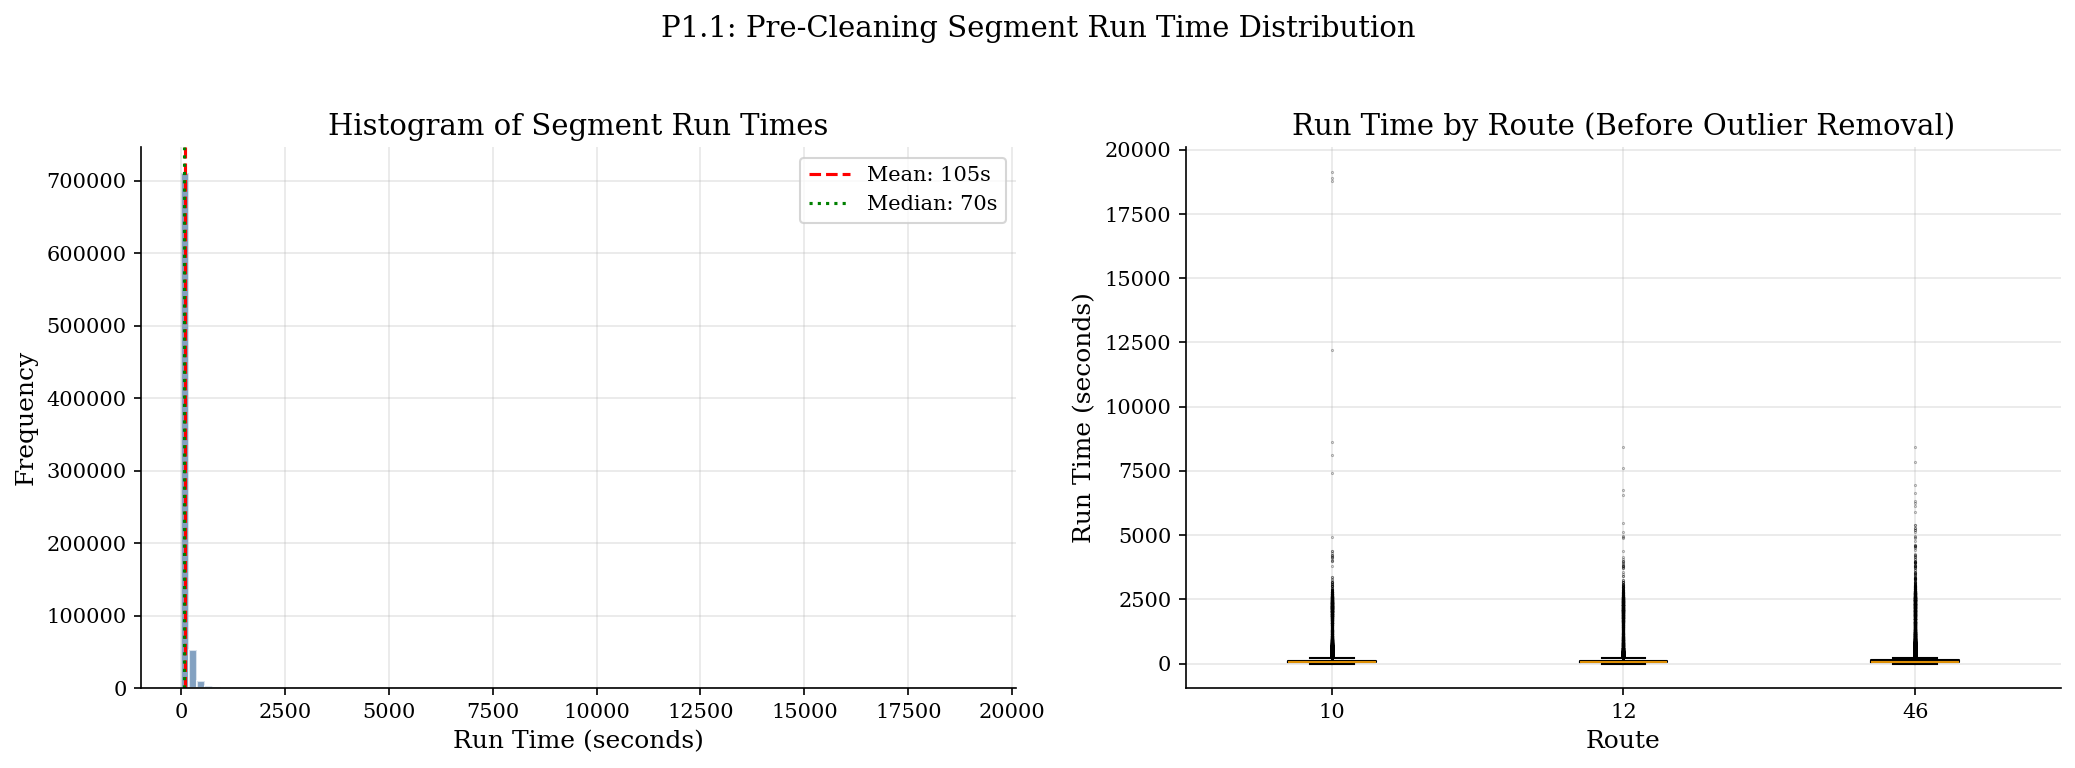

Pre-cleaning run time statistics:
  Count:  782,719
  Mean:   105.5s
  Median: 70.0s
  Std:    188.1s
  Min:    0.0s
  Max:    19140.0s (319.0 min)
  > 600s: 8,713 (1.11%)


In [5]:
# Plot P1.1: Pre-Cleaning Run Time Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

run_times_pre = df['run_time_in_seconds'].dropna()

# Histogram
axes[0].hist(run_times_pre, bins=100, color='#4e79a7', edgecolor='white', alpha=0.7)
axes[0].set_xlabel('Run Time (seconds)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram of Segment Run Times')
axes[0].axvline(run_times_pre.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {run_times_pre.mean():.0f}s')
axes[0].axvline(run_times_pre.median(), color='green', linestyle=':', linewidth=1.5,
                label=f'Median: {run_times_pre.median():.0f}s')
axes[0].legend()

# Box plot by route
route_names = sorted(df['route_short_name'].dropna().unique())
route_data = [df[df['route_short_name'] == r]['run_time_in_seconds'].dropna().values
              for r in route_names]
bp = axes[1].boxplot(route_data, labels=[str(r) for r in route_names],
                     showfliers=True, flierprops=dict(marker='.', markersize=1, alpha=0.3))
axes[1].set_xlabel('Route')
axes[1].set_ylabel('Run Time (seconds)')
axes[1].set_title('Run Time by Route (Before Outlier Removal)')

fig.suptitle('P1.1: Pre-Cleaning Segment Run Time Distribution', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P1_1_pre_cleaning_run_time.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P1_1_pre_cleaning_run_time.pdf'), bbox_inches='tight')
plt.show()

print(f"Pre-cleaning run time statistics:")
print(f"  Count:  {len(run_times_pre):,}")
print(f"  Mean:   {run_times_pre.mean():.1f}s")
print(f"  Median: {run_times_pre.median():.1f}s")
print(f"  Std:    {run_times_pre.std():.1f}s")
print(f"  Min:    {run_times_pre.min():.1f}s")
print(f"  Max:    {run_times_pre.max():.1f}s ({run_times_pre.max()/60:.1f} min)")
print(f"  > 600s: {(run_times_pre > 600).sum():,} ({(run_times_pre > 600).sum()/len(run_times_pre)*100:.2f}%)")

---
## 4. Outlier Removal (IQR Method per Segment + Direction)

### Method
We apply the **Interquartile Range (IQR)** method with a threshold of 1.5x to detect and remove outliers in `run_time_in_seconds`. Critically, we compute IQR bounds **per segment and direction** rather than globally. This is essential because:

1. **Spatial heterogeneity:** Different segments have inherently different travel time distributions (e.g., a segment through a busy intersection vs. an expressway segment). A global threshold would either over-filter short segments or under-filter long segments.
2. **Direction matters:** The same segment may have different characteristics in each direction (e.g., uphill vs. downhill, or different traffic signal timing).

### Thesis Connection (RQ3)
Per-segment outlier removal preserves the natural variability structure across segments while removing only genuinely anomalous observations. This is particularly important for RQ3 (segment-level uncertainty decomposition), where we need reliable per-segment distributions to attribute uncertainty to specific route portions.

### Why IQR over Z-Score?
The IQR method is robust to non-normal distributions and heavy tails, which are characteristic of travel time data. Z-score methods assume approximate normality and can fail when the data is right-skewed, as travel times typically are.

In [6]:
# # Store pre-outlier data for comparison plot
# df_before_outlier = df.copy()

# # Apply IQR-based outlier removal per segment and direction
# df, outliers_df = detect_and_remove_outliers(
#     df,
#     column='run_time_in_seconds',
#     method='iqr',
#     threshold=1.5,
#     group_cols=['segment', 'direction']
# )

# print(f"\nSummary:")
# print(f"  Before outlier removal: {len(df_before_outlier):,} records")
# print(f"  After outlier removal:  {len(df):,} records")
# print(f"  Outliers removed:       {len(outliers_df):,} records")
# print(f"  Removal rate:           {len(outliers_df)/len(df_before_outlier)*100:.2f}%")

---
## Table T1.1: Outlier Removal Summary by Route and Direction

This table provides a granular breakdown of outlier removal impact, showing that the IQR method removes a consistent proportion of records across routes and directions, confirming that the outlier treatment is not biased toward any particular route.

In [7]:
# # Table T1.1: Outlier Removal Summary by Route and Direction
# before_counts = df_before_outlier.groupby(['route_short_name', 'direction']).size().reset_index(name='before')
# after_counts = df.groupby(['route_short_name', 'direction']).size().reset_index(name='after')
# outlier_counts = outliers_df.groupby(['route_short_name', 'direction']).size().reset_index(name='removed')

# t11 = before_counts.merge(after_counts, on=['route_short_name', 'direction'], how='left')
# t11 = t11.merge(outlier_counts, on=['route_short_name', 'direction'], how='left')
# t11['removed'] = t11['removed'].fillna(0).astype(int)
# t11['removal_pct'] = (t11['removed'] / t11['before'] * 100).round(2)

# # Add totals row
# totals = pd.DataFrame([{
#     'route_short_name': 'TOTAL',
#     'direction': '-',
#     'before': t11['before'].sum(),
#     'after': t11['after'].sum(),
#     'removed': t11['removed'].sum(),
#     'removal_pct': round(t11['removed'].sum() / t11['before'].sum() * 100, 2)
# }])
# t11 = pd.concat([t11, totals], ignore_index=True)

# t11.columns = ['Route', 'Direction', 'Before', 'After', 'Removed', 'Removal %']
# display(t11)

# # Save as LaTeX
# t11.to_latex(
#     os.path.join(TABLE_DIR, 'T1_1_outlier_removal_summary.tex'),
#     index=False,
#     caption='Outlier Removal Summary by Route and Direction (IQR method, threshold=1.5)',
#     label='tab:outlier_removal'
# )
# print(f"\nTable saved to {os.path.join(TABLE_DIR, 'T1_1_outlier_removal_summary.tex')}")

---
## Plot P1.2: Before vs After Outlier Removal

Overlapping histograms demonstrate the effect of IQR-based outlier removal on the segment run time distribution. The "after" distribution should be tighter and more symmetric, with extreme tails trimmed while preserving the core distribution shape.

In [8]:
# # Plot P1.2: Before vs After Outlier Removal
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# run_times_before = df_before_outlier['run_time_in_seconds'].dropna()
# run_times_after = df['run_time_in_seconds'].dropna()

# # Overlapping histograms
# axes[0].hist(run_times_before, bins=100, alpha=0.5, color='#e15759',
#              label=f'Before ({len(run_times_before):,})', density=True, edgecolor='white')
# axes[0].hist(run_times_after, bins=100, alpha=0.5, color='#4e79a7',
#              label=f'After ({len(run_times_after):,})', density=True, edgecolor='white')
# axes[0].set_xlabel('Run Time (seconds)')
# axes[0].set_ylabel('Density')
# axes[0].set_title('Distribution Comparison')
# axes[0].legend()

# # Zoomed view (0-300s range)
# axes[1].hist(run_times_before[run_times_before <= 300], bins=80, alpha=0.5, color='#e15759',
#              label='Before', density=True, edgecolor='white')
# axes[1].hist(run_times_after[run_times_after <= 300], bins=80, alpha=0.5, color='#4e79a7',
#              label='After', density=True, edgecolor='white')
# axes[1].set_xlabel('Run Time (seconds)')
# axes[1].set_ylabel('Density')
# axes[1].set_title('Zoomed View (0-300s)')
# axes[1].legend()

# fig.suptitle('P1.2: Segment Run Time Distribution Before vs After Outlier Removal', fontsize=14, y=1.02)
# plt.tight_layout()
# fig.savefig(os.path.join(FIG_DIR, 'P1_2_before_after_outlier_removal.png'), dpi=300, bbox_inches='tight')
# fig.savefig(os.path.join(FIG_DIR, 'P1_2_before_after_outlier_removal.pdf'), bbox_inches='tight')
# plt.show()

# print(f"Before: mean={run_times_before.mean():.1f}s, std={run_times_before.std():.1f}s, "
#       f"max={run_times_before.max():.0f}s")
# print(f"After:  mean={run_times_after.mean():.1f}s, std={run_times_after.std():.1f}s, "
#       f"max={run_times_after.max():.0f}s")

---
## 5. Filter Incomplete Trips

Trips with too few segments are incomplete -- either the bus terminated early, or the data collection system missed segments. Including them would:
1. Bias route-level travel time aggregations downward (fewer segments = shorter total time)
2. Create inconsistent feature vectors for the XGBoost model
3. Invalidate segment-level decomposition in RQ3 (cannot decompose a partial trip)

We require a minimum of **30 segments** per trip, which was determined in Phase 0 based on the distribution of segments per trip.

In [9]:
n_before_filter = len(df)
n_trips_before = df['trip_id'].nunique()

df = filter_incomplete_trips(df, min_segments=30)

n_after_filter = len(df)
n_trips_after = df['trip_id'].nunique()

print(f"\nSegment records: {n_before_filter:,} -> {n_after_filter:,} "
      f"(removed {n_before_filter - n_after_filter:,})")
print(f"Trips: {n_trips_before:,} -> {n_trips_after:,} "
      f"(removed {n_trips_before - n_trips_after:,})")
print(f"\nSegments per trip after filtering:")
print(df.groupby('trip_id')['segment'].nunique().describe())

Trip filtering (min_segments=30): 19,685 -> 19,685 trips (removed 0, 0.0%)

Segment records: 782,719 -> 782,719 (removed 0)
Trips: 19,685 -> 19,685 (removed 0)

Segments per trip after filtering:
count    19685.000000
mean        39.762205
std          2.834580
min         35.000000
25%         38.000000
50%         40.000000
75%         42.000000
max         55.000000
Name: segment, dtype: float64


---
## 6. Compute Total Segment Travel Time

Each segment's total travel time is the sum of its **run time** (time spent moving between stops) and **dwell time** (time spent at the stop for passenger boarding/alighting). This combined metric is the target variable for segment-level modeling.

In [10]:
df = compute_segment_travel_time(df)

print("Total segment time (run_time + dwell_time) statistics:")
print(df['total_segment_time'].describe().round(2))

print(f"\nCorrelation between run_time and dwell_time: "
      f"{df['run_time_in_seconds'].corr(df['dwell_time_in_seconds']):.4f}")
print(f"Mean run_time:  {df['run_time_in_seconds'].mean():.1f}s")
print(f"Mean dwell_time: {df['dwell_time_in_seconds'].mean():.1f}s")
print(f"Mean total_segment_time: {df['total_segment_time'].mean():.1f}s")

Total segment time (run_time + dwell_time) statistics:
count    782719.00
mean        143.32
std         325.99
min           0.00
25%          65.00
50%          97.00
75%         143.00
max       38280.00
Name: total_segment_time, dtype: float64

Correlation between run_time and dwell_time: 0.7906
Mean run_time:  105.5s
Mean dwell_time: 37.9s
Mean total_segment_time: 143.3s


In [11]:
# n_before_seg1 = len(df)
# mask_seg1_dir1 = (df['direction'] == 1) & (df['segment'] == 1)
# n_removed = mask_seg1_dir1.sum()
# df = df[~mask_seg1_dir1].reset_index(drop=True)

# print(f'Removed first segment of Direction 1: {n_removed:,} rows')
# print(f'Before: {n_before_seg1:,}  After: {len(df):,}')
# print(f'Affected trips: {df[df["direction"]==1]["trip_id"].nunique():,} direction-1 trips now exclude segment 1')

---
## 7. Create Route-Level Dataset

The route-level dataset aggregates all segment records within each trip into a single row, computing total travel time (sum of all segment run + dwell times), total run time, total dwell time, and the number of segments. This is the primary dataset for route-level conformal prediction experiments (RQ1 and RQ2).

### Thesis Connection
Route-level travel time prediction is the main prediction task. The XGBoost model predicts total route travel time, and conformal prediction wraps these point predictions with calibrated uncertainty intervals.

In [12]:
route_df = aggregate_to_route_level(df)

print(f"Route-level dataset shape: {route_df.shape}")
print(f"\nDescriptive statistics:")
display(route_df.describe().round(2))

print(f"\nFirst 5 rows:")
display(route_df.head())

Route-level dataset shape: (19685, 11)

Descriptive statistics:


,trip_id,total_run_time_seconds,total_dwell_time_seconds,num_segments,direction,date,route_short_name,deviceid,departure_time,total_travel_time_seconds
count,19685.00,19685.00,19685.00,19685.00,19685.00,19685,19685.00,1.968500e+04,19685,19685.00
mean,14773.09,4193.56,1505.01,39.76,1.48,2024-08-24 15:54:33.741427712,25.35,2.605407e+06,2024-08-25 05:01:36.024333312,5698.57
min,1.00,1017.00,80.00,35.00,1.00,2024-07-29 00:00:00,10.00,5.320000e+02,2024-07-29 05:59:12,1435.00
25%,7477.00,3452.00,978.00,38.00,1.00,2024-08-11 00:00:00,10.00,7.950000e+02,2024-08-11 19:36:14,4506.00
50%,14399.00,3921.00,1164.00,40.00,1.00,2024-08-24 00:00:00,12.00,1.136000e+03,2024-08-24 13:22:18,5113.00
75%,21919.00,4763.00,1603.00,42.00,2.00,2024-09-08 00:00:00,46.00,2.368000e+03,2024-09-08 13:04:48,6278.00
max,29517.00,23003.00,20641.00,55.00,2.00,2024-09-21 00:00:00,46.00,5.890880e+08,2024-09-21 21:14:00,42924.00
std,8512.60,1092.18,875.15,2.83,0.50,NaN,17.30,3.907547e+07,NaN,1824.59



First 5 rows:


,trip_id,total_run_time_seconds,total_dwell_time_seconds,num_segments,direction,date,route_id,route_short_name,deviceid,departure_time,total_travel_time_seconds
0,1,4161.0,821.0,41,2,2024-07-29,a3d30efc-b517-4ed6-b6a7-f5a87a3d5fa0,46,2315,2024-07-29 06:45:16,4982.0
1,6,3829.0,1060.0,42,2,2024-07-29,a3d30efc-b517-4ed6-b6a7-f5a87a3d5fa0,46,4100,2024-07-29 06:18:47,4889.0
2,7,2915.0,848.0,35,1,2024-07-29,d626b854-27aa-41d4-8625-ebafa73d8f21,10,782,2024-07-29 06:15:30,3763.0
3,10,2824.0,821.0,35,1,2024-07-29,c453217f-9f9d-49ce-8b32-14a6b7013691,12,4103,2024-07-29 05:59:12,3645.0
4,11,4126.0,1095.0,43,2,2024-07-29,a3d30efc-b517-4ed6-b6a7-f5a87a3d5fa0,46,1114,2024-07-29 06:35:26,5221.0


---
## Table T1.2: Route-Level Dataset Summary

This summary table provides key statistics of the route-level dataset, broken down by route and direction. It quantifies the scale of the prediction task and highlights inter-route differences in travel time magnitude and variability.

In [13]:
# Table T1.2: Route-Level Dataset Summary
route_summary = route_df.groupby(['route_short_name', 'direction']).agg(
    total_trips=('trip_id', 'count'),
    mean_travel_time=('total_travel_time_seconds', 'mean'),
    std_travel_time=('total_travel_time_seconds', 'std'),
    median_travel_time=('total_travel_time_seconds', 'median'),
    min_travel_time=('total_travel_time_seconds', 'min'),
    max_travel_time=('total_travel_time_seconds', 'max'),
    mean_segments=('num_segments', 'mean')
).reset_index()

# Add overall row
overall = pd.DataFrame([{
    'route_short_name': 'ALL',
    'direction': '-',
    'total_trips': route_df.shape[0],
    'mean_travel_time': route_df['total_travel_time_seconds'].mean(),
    'std_travel_time': route_df['total_travel_time_seconds'].std(),
    'median_travel_time': route_df['total_travel_time_seconds'].median(),
    'min_travel_time': route_df['total_travel_time_seconds'].min(),
    'max_travel_time': route_df['total_travel_time_seconds'].max(),
    'mean_segments': route_df['num_segments'].mean()
}])
route_summary = pd.concat([route_summary, overall], ignore_index=True)

# Format for display
route_summary_display = route_summary.copy()
for col in ['mean_travel_time', 'std_travel_time', 'median_travel_time',
            'min_travel_time', 'max_travel_time', 'mean_segments']:
    route_summary_display[col] = route_summary_display[col].round(1)

route_summary_display.columns = ['Route', 'Dir', 'Trips', 'Mean (s)', 'Std (s)',
                                  'Median (s)', 'Min (s)', 'Max (s)', 'Mean Segs']
display(route_summary_display)

# Save as LaTeX
route_summary_display.to_latex(
    os.path.join(TABLE_DIR, 'T1_2_route_level_summary.tex'),
    index=False,
    caption='Route-Level Dataset Summary Statistics',
    label='tab:route_level_summary'
)
print(f"\nTable saved to {os.path.join(TABLE_DIR, 'T1_2_route_level_summary.tex')}")

,Route,Dir,Trips,Mean (s),Std (s),Median (s),Min (s),Max (s),Mean Segs
0,10,1,3317,6356.3,2492.8,5526.0,1963.0,42924.0,35.6
1,10,2,3133,4792.7,711.9,4687.0,1770.0,13087.0,39.6
2,12,1,2906,5944.7,2151.3,5098.0,1477.0,22846.0,38.3
3,12,2,2220,4662.1,732.9,4517.5,2570.0,9989.0,43.0
4,46,1,3933,6581.0,2005.4,6038.0,1435.0,20423.0,40.5
5,46,2,4176,5404.5,833.3,5282.0,1601.0,16407.0,41.8
6,ALL,-,19685,5698.6,1824.6,5113.0,1435.0,42924.0,39.8



Table saved to ../outputs/tables/T1_2_route_level_summary.tex


---
## Plot P1.3: Route-Level Travel Time by Route & Direction

Box plots reveal the travel time distribution characteristics for each route-direction combination. Differences in spread (IQR) across routes indicate varying levels of inherent predictability, which directly impacts the expected width of conformal prediction intervals.

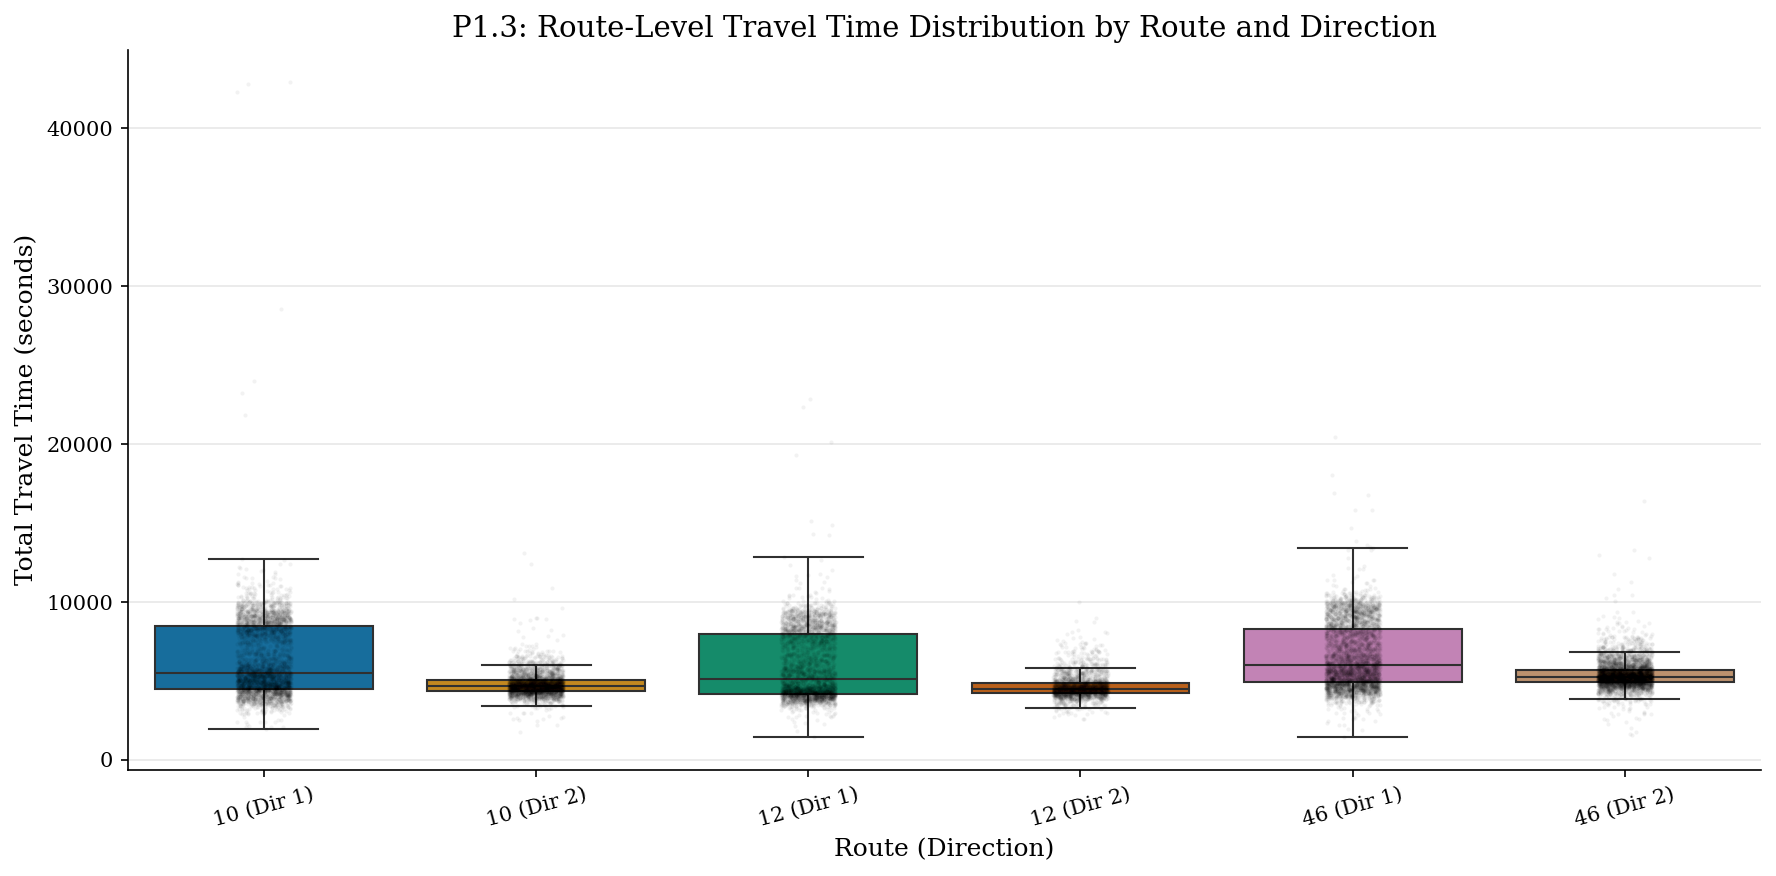

In [14]:
# Plot P1.3: Route-Level Travel Time by Route & Direction
fig, ax = plt.subplots(figsize=(12, 6))

# Create a combined label for route + direction
route_df['route_dir'] = route_df['route_short_name'].astype(str) + ' (Dir ' + route_df['direction'].astype(str) + ')'
route_dir_order = sorted(route_df['route_dir'].unique())

sns.boxplot(
    data=route_df, x='route_dir', y='total_travel_time_seconds',
    order=route_dir_order, palette='colorblind', showfliers=False, ax=ax
)

# Overlay strip plot for density
sns.stripplot(
    data=route_df, x='route_dir', y='total_travel_time_seconds',
    order=route_dir_order, color='black', alpha=0.05, size=2, jitter=True, ax=ax
)

ax.set_xlabel('Route (Direction)')
ax.set_ylabel('Total Travel Time (seconds)')
ax.set_title('P1.3: Route-Level Travel Time Distribution by Route and Direction')
plt.xticks(rotation=15)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P1_3_route_travel_time_boxplot.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P1_3_route_travel_time_boxplot.pdf'), bbox_inches='tight')
plt.show()

---
## 8. Apply Temporal Split Strategy

### Strategy
The temporal split is designed to evaluate conformal prediction under **increasing temporal distance** from the calibration period:

| Period | Weeks | Date Range | Purpose |
|--------|-------|------------|--------|
| **Train** | W1-W3 | Jul 29 - Aug 18 | XGBoost model training |
| **Calibration** | W4 | Aug 19 - Aug 25 | Compute nonconformity scores for conformal prediction |
| **Test-Near** | W5 | Aug 26 - Sep 1 | Test immediately after calibration (minimal drift) |
| **Test-Mid** | W6 | Sep 2 - Sep 8 | Test with moderate temporal distance |
| **Test-Far** | W7-W8 | Sep 9 - Sep 21 | Test with maximum temporal distance (greatest drift) |

### Thesis Connection (RQ1, RQ2)
This split design is central to addressing **RQ1**: by comparing PICP (Prediction Interval Coverage Probability) across test_near, test_mid, and test_far, we directly measure how temporal distance from calibration affects coverage validity. **RQ2** builds on this by evaluating whether online conformal methods can adapt their calibration to recover coverage in test_mid and test_far where static methods are expected to degrade.

### Why This Split?
- **Three training weeks** provide sufficient data for a robust XGBoost model
- **One calibration week** follows standard conformal prediction practice (exchangeability assumed within calibration period)
- **Three test periods at increasing distance** create a natural gradient for studying coverage degradation

In [15]:
# Apply temporal split to segment-level data
print("=== Segment-Level Temporal Splits ===")
segment_splits = get_temporal_split_by_period(df)

# Add temporal_period labels to segment data
df = label_temporal_period(df)
print(f"\nTemporal period distribution (segment-level):")
print(df['temporal_period'].value_counts())

print("\n=== Route-Level Temporal Splits ===")
route_splits = get_temporal_split_by_period(route_df)

# Add temporal_period labels to route data
route_df = label_temporal_period(route_df)
print(f"\nTemporal period distribution (route-level):")
print(route_df['temporal_period'].value_counts())

=== Segment-Level Temporal Splits ===
  train: 302,609 records (21 days)
  calibration: 109,308 records (7 days)
  test_near: 108,358 records (7 days)
  test_mid: 73,161 records (5 days)
  test_far: 189,283 records (13 days)

Temporal period distribution (segment-level):
temporal_period
train          302609
test_far       189283
calibration    109308
test_near      108358
test_mid        73161
Name: count, dtype: int64

=== Route-Level Temporal Splits ===
  train: 7,619 records (21 days)
  calibration: 2,745 records (7 days)
  test_near: 2,726 records (7 days)
  test_mid: 1,844 records (5 days)
  test_far: 4,751 records (13 days)

Temporal period distribution (route-level):
temporal_period
train          7619
test_far       4751
calibration    2745
test_near      2726
test_mid       1844
Name: count, dtype: int64


---
## Table T1.3: Temporal Split Statistics

This table provides a comprehensive overview of the temporal split, including date ranges, number of active days, record counts at both segment and route levels, and the purpose of each period. This information is essential for the thesis methodology section.

In [16]:
# Table T1.3: Temporal Split Statistics
from utils.temporal_splits import DEFAULT_SPLIT

split_stats = []
purpose_map = {
    'train': 'XGBoost model training',
    'calibration': 'Conformal calibration (nonconformity scores)',
    'test_near': 'Test: minimal temporal drift',
    'test_mid': 'Test: moderate temporal drift',
    'test_far': 'Test: maximum temporal drift'
}

for period in ['train', 'calibration', 'test_near', 'test_mid', 'test_far']:
    weeks = DEFAULT_SPLIT[period]
    start_date = min(pd.Timestamp(WEEK_BOUNDARIES[w][0]) for w in weeks)
    end_date = max(pd.Timestamp(WEEK_BOUNDARIES[w][1]) for w in weeks)
    
    seg_data = segment_splits[period]
    route_data = route_splits[period]
    
    split_stats.append({
        'Split': period.replace('_', ' ').title(),
        'Weeks': ', '.join(weeks),
        'Date Range': f"{start_date.strftime('%b %d')} - {end_date.strftime('%b %d')}",
        'Days': seg_data['date'].nunique(),
        'Segment Records': f"{len(seg_data):,}",
        'Trip Records': f"{len(route_data):,}",
        'Purpose': purpose_map[period]
    })

t13 = pd.DataFrame(split_stats)
display(t13)

# Save as LaTeX
t13.to_latex(
    os.path.join(TABLE_DIR, 'T1_3_temporal_split_statistics.tex'),
    index=False,
    caption='Temporal Split Strategy: Date Ranges, Record Counts, and Purpose',
    label='tab:temporal_splits'
)
print(f"\nTable saved to {os.path.join(TABLE_DIR, 'T1_3_temporal_split_statistics.tex')}")

,Split,Weeks,Date Range,Days,Segment Records,Trip Records,Purpose
0,Train,"W1, W2, W3",Jul 29 - Aug 18,21,"302,609","7,619",XGBoost model training
1,Calibration,W4,Aug 19 - Aug 25,7,"109,308","2,745",Conformal calibration (nonconformity scores)
2,Test Near,W5,Aug 26 - Sep 01,7,"108,358","2,726",Test: minimal temporal drift
3,Test Mid,W6,Sep 02 - Sep 08,5,"73,161","1,844",Test: moderate temporal drift
4,Test Far,"W7, W8",Sep 09 - Sep 21,13,"189,283","4,751",Test: maximum temporal drift



Table saved to ../outputs/tables/T1_3_temporal_split_statistics.tex


---
## Plot P1.4: Temporal Split Visualization

This timeline visualization shows the temporal structure of the dataset with color-coded bands for each split period and the daily mean travel time overlaid. It provides an intuitive overview of the experimental design for the thesis methodology section.

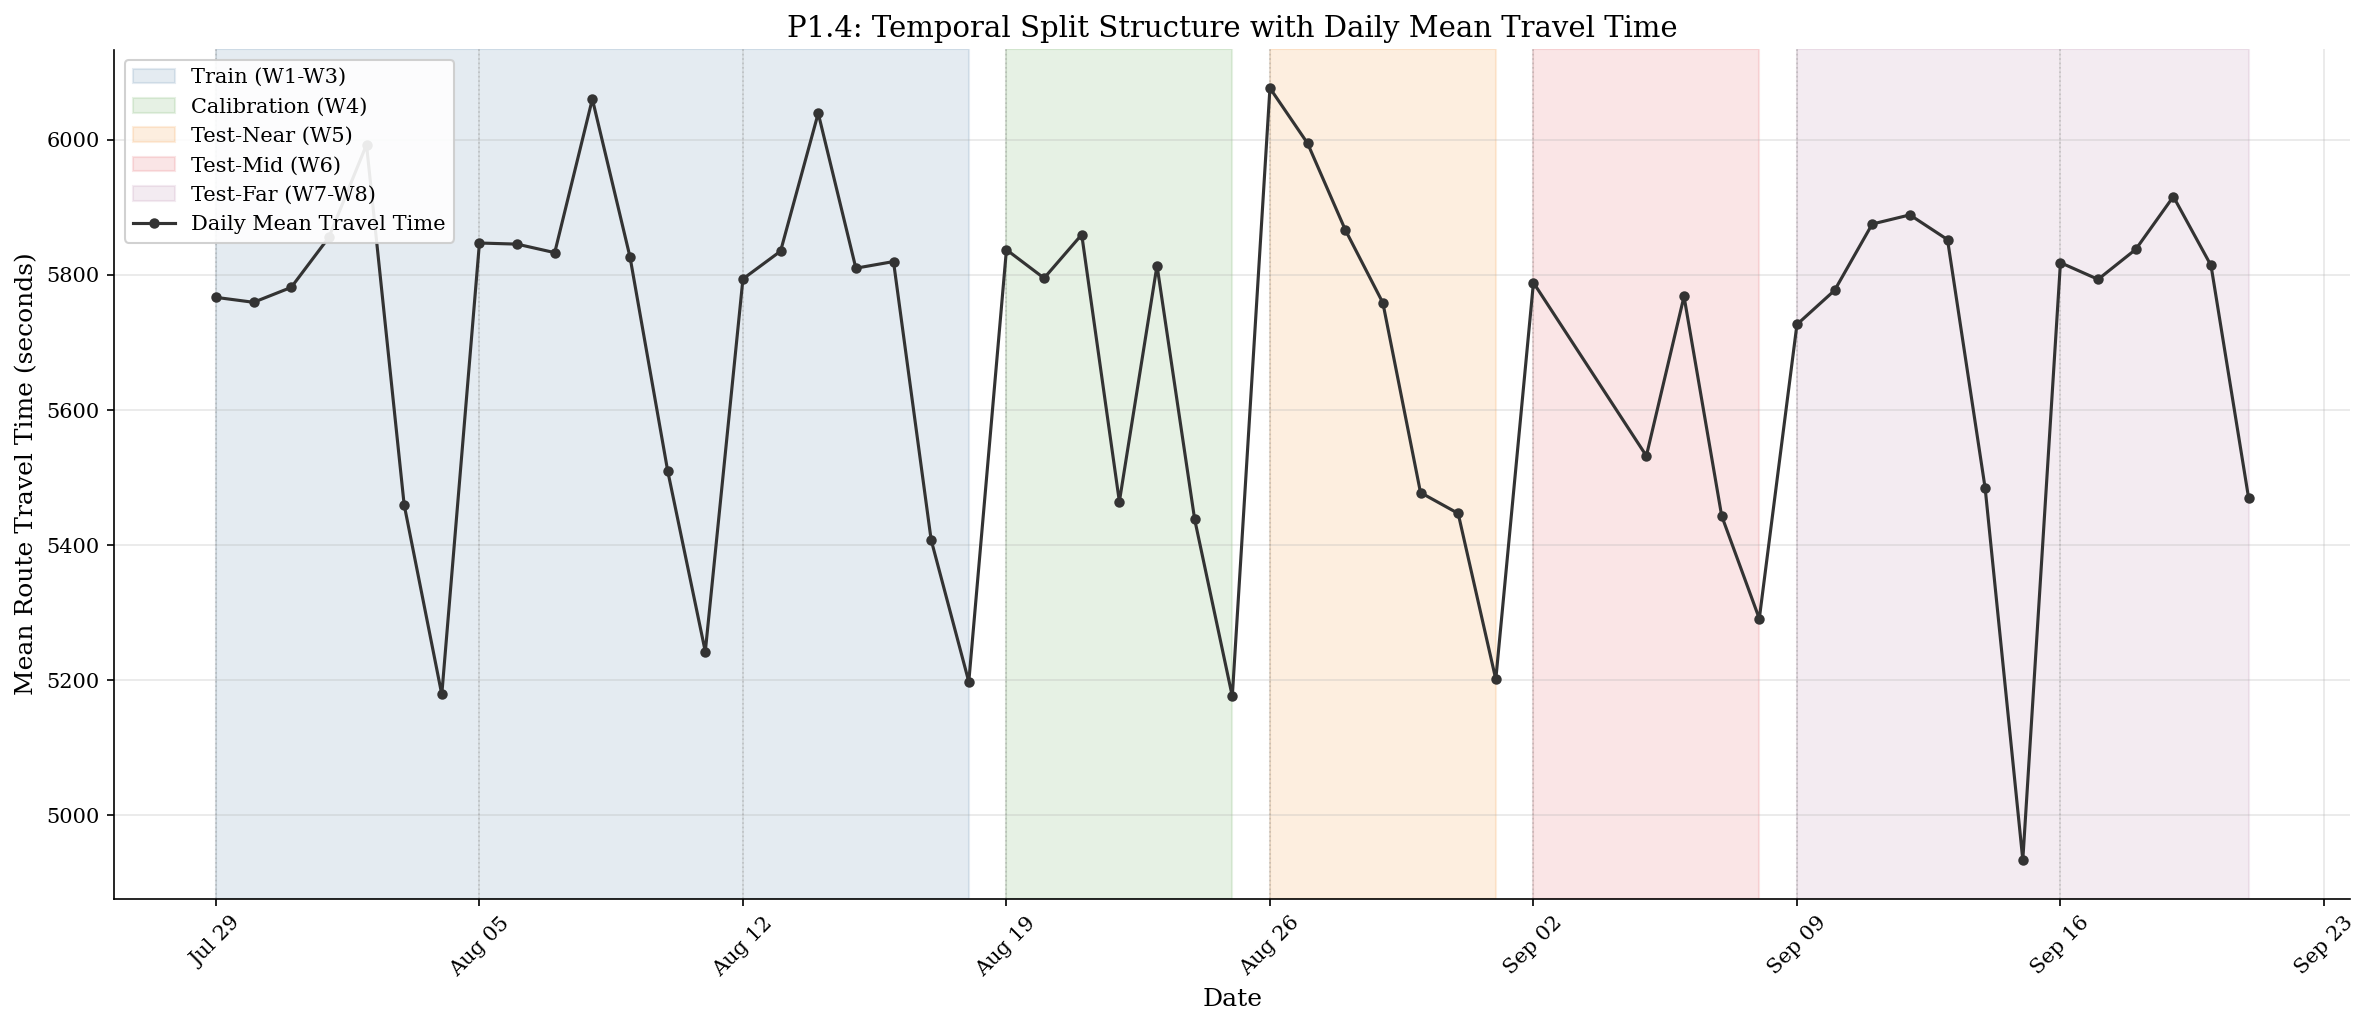

In [17]:
# Plot P1.4: Temporal Split Visualization
fig, ax = plt.subplots(figsize=(16, 7))

# Color scheme for periods
period_colors = {
    'train': '#4e79a7',
    'calibration': '#59a14f',
    'test_near': '#f28e2b',
    'test_mid': '#e15759',
    'test_far': '#b07aa1'
}

period_labels = {
    'train': 'Train (W1-W3)',
    'calibration': 'Calibration (W4)',
    'test_near': 'Test-Near (W5)',
    'test_mid': 'Test-Mid (W6)',
    'test_far': 'Test-Far (W7-W8)'
}

# Draw color-coded background bands for each period
for period, weeks in DEFAULT_SPLIT.items():
    start_date = min(pd.Timestamp(WEEK_BOUNDARIES[w][0]) for w in weeks)
    end_date = max(pd.Timestamp(WEEK_BOUNDARIES[w][1]) for w in weeks)
    ax.axvspan(start_date, end_date, alpha=0.15, color=period_colors[period],
               label=period_labels[period])

# Compute daily mean travel time from route-level data
daily_mean = route_df.groupby('date')['total_travel_time_seconds'].mean().sort_index()

# Plot daily mean travel time
ax.plot(daily_mean.index, daily_mean.values, 'o-', markersize=4, linewidth=1.5,
        color='#333333', label='Daily Mean Travel Time', zorder=5)

# Add week boundary markers
for week, (start, end) in WEEK_BOUNDARIES.items():
    ax.axvline(pd.Timestamp(start), color='gray', linestyle=':', alpha=0.3, linewidth=0.8)

ax.set_xlabel('Date')
ax.set_ylabel('Mean Route Travel Time (seconds)')
ax.set_title('P1.4: Temporal Split Structure with Daily Mean Travel Time')
ax.legend(loc='upper left', framealpha=0.9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=45)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P1_4_temporal_split_timeline.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P1_4_temporal_split_timeline.pdf'), bbox_inches='tight')
plt.show()

---
## Plot P1.5: Distribution Comparison Across Temporal Splits

Overlapping kernel density estimates (KDE) for each temporal period visualize whether and how the travel time distribution shifts across the train, calibration, and test periods. If the test distributions diverge visibly from the calibration distribution, this provides direct visual evidence for the exchangeability violation that underpins RQ1.

### Thesis Connection (RQ1)
Visual confirmation of distribution shift validates the core premise of RQ1: that temporal drift causes the calibration set to become non-representative of the test set, potentially leading to invalid coverage guarantees from static conformal prediction.

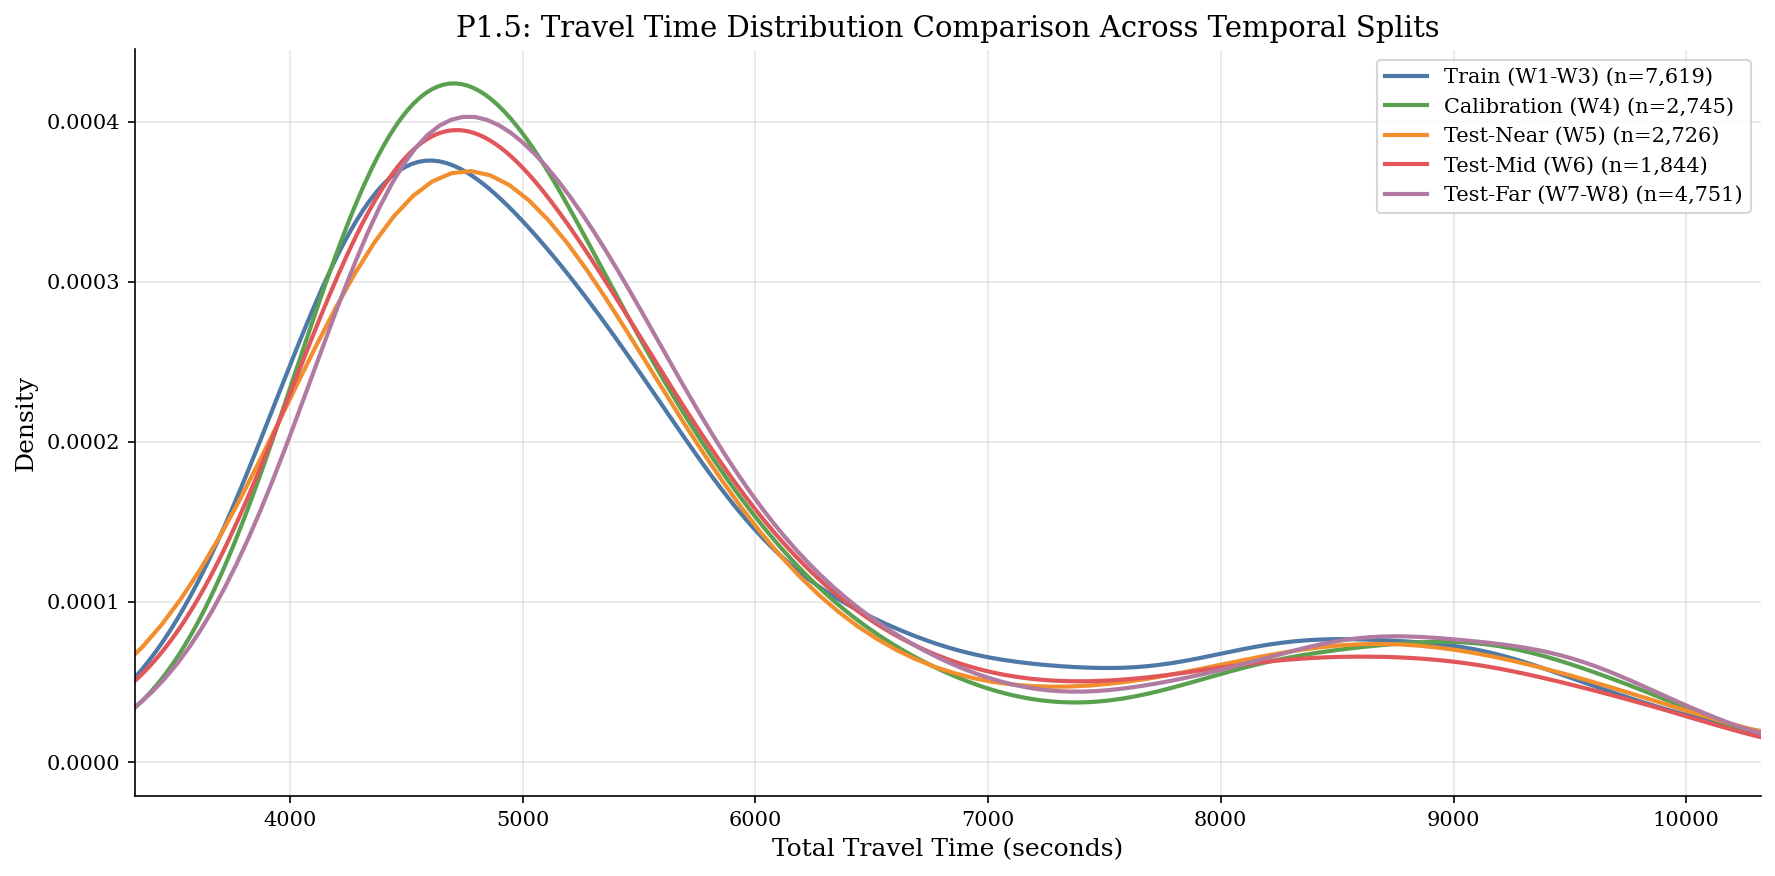


Travel time statistics per temporal split:
  Train (W1-W3)              mean=5713s  std=1773s  median=5125s
  Calibration (W4)           mean=5651s  std=1661s  median=5065s
  Test-Near (W5)             mean=5711s  std=2352s  median=5048s
  Test-Mid (W6)              mean=5576s  std=1640s  median=5062s
  Test-Far (W7-W8)           mean=5743s  std=1713s  median=5179s

--- Thesis Connection ---
Visual confirmation of distribution shift validates RQ1: temporal drift causes
the calibration set to become non-representative of later test periods,
potentially violating the exchangeability assumption that underpins static
conformal prediction coverage guarantees.


In [18]:
# Plot P1.5: Distribution Comparison Across Splits
fig, ax = plt.subplots(figsize=(12, 6))

period_order = ['train', 'calibration', 'test_near', 'test_mid', 'test_far']
period_display = {
    'train': 'Train (W1-W3)',
    'calibration': 'Calibration (W4)',
    'test_near': 'Test-Near (W5)',
    'test_mid': 'Test-Mid (W6)',
    'test_far': 'Test-Far (W7-W8)'
}

for period in period_order:
    if period in route_splits and len(route_splits[period]) > 0:
        data = route_splits[period]['total_travel_time_seconds'].dropna()
        data.plot.kde(
            ax=ax, label=f"{period_display[period]} (n={len(data):,})",
            color=period_colors[period], linewidth=2
        )

ax.set_xlabel('Total Travel Time (seconds)')
ax.set_ylabel('Density')
ax.set_title('P1.5: Travel Time Distribution Comparison Across Temporal Splits')
ax.legend(loc='upper right')

# Set reasonable x-axis limits based on data
all_times = route_df['total_travel_time_seconds'].dropna()
ax.set_xlim(all_times.quantile(0.01), all_times.quantile(0.99))

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P1_5_distribution_comparison_splits.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P1_5_distribution_comparison_splits.pdf'), bbox_inches='tight')
plt.show()

# Print summary statistics per split
print("\nTravel time statistics per temporal split:")
for period in period_order:
    if period in route_splits and len(route_splits[period]) > 0:
        data = route_splits[period]['total_travel_time_seconds']
        print(f"  {period_display[period]:25s}  "
              f"mean={data.mean():.0f}s  std={data.std():.0f}s  "
              f"median={data.median():.0f}s")

print("\n--- Thesis Connection ---")
print("Visual confirmation of distribution shift validates RQ1: temporal drift causes")
print("the calibration set to become non-representative of later test periods,")
print("potentially violating the exchangeability assumption that underpins static")
print("conformal prediction coverage guarantees.")

---
## Plot P1.6: Route Travel Time Distribution by Week and Split

This plot decomposes the temporal split into its underlying weekly structure, showing the travel time distribution for each ISO week (W1-W8) color-coded by the temporal split assignment. Unlike P1.5 which aggregates entire split periods, this view exposes week-to-week variation *within* a split (e.g., across the three training weeks) as well as the boundaries between splits.

### Thesis Connection (RQ1)
Week-level granularity helps distinguish two failure modes for static conformal prediction:
1. **Gradual drift:** Adjacent weeks differ only slightly, but the cumulative shift between calibration (W4) and test-far (W7-W8) is substantial.
2. **Abrupt shifts:** A specific week deviates sharply from its neighbors (e.g., due to schedule changes or weather), producing localized coverage failures.

Visual inspection of week-level distributions clarifies which mechanism dominates in this dataset.

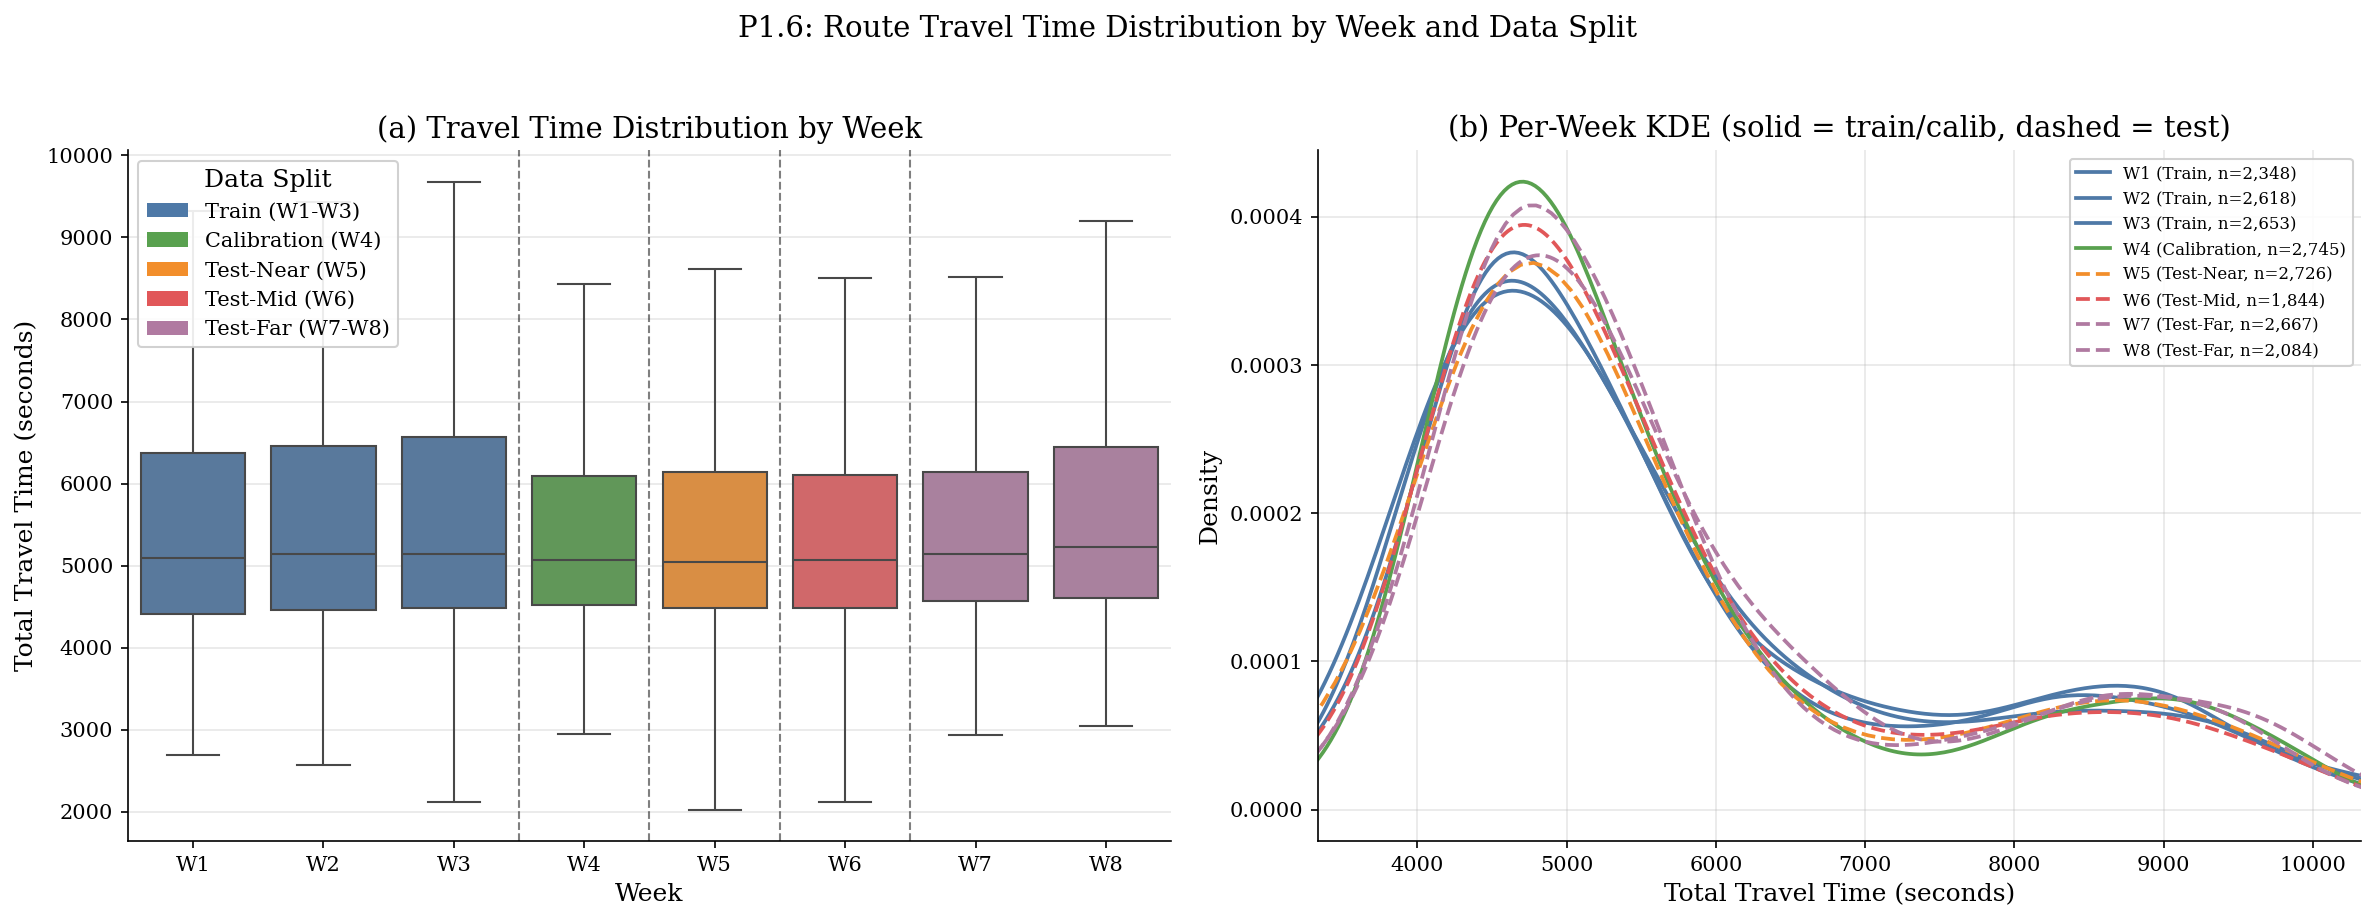


Per-week travel time statistics:


,Split,Trips,Mean (s),Std (s),Median (s)
week,,,,,
W1,Train (W1-W3),2348,5680.3,1810.5,5096.5
W2,Train (W1-W3),2618,5728.4,1796.3,5136.0
W3,Train (W1-W3),2653,5726.3,1715.4,5141.0
W4,Calibration (W4),2745,5651.2,1660.8,5065.0
W5,Test-Near (W5),2726,5711.4,2351.8,5048.0
W6,Test-Mid (W6),1844,5575.7,1639.6,5062.5
W7,Test-Far (W7-W8),2667,5696.3,1718.2,5140.0
W8,Test-Far (W7-W8),2084,5803.6,1706.0,5230.0


In [19]:
# Plot P1.6: Route Travel Time Distribution by Week and Split

# Map each row to its ISO-style week label (W1-W8) using WEEK_BOUNDARIES.
def _week_for_date(d):
    d = pd.Timestamp(d).normalize()
    for week, (start, end) in WEEK_BOUNDARIES.items():
        if pd.Timestamp(start) <= d <= pd.Timestamp(end):
            return week
    return None

plot_df = route_df.copy()
plot_df['week'] = plot_df['date'].apply(_week_for_date)
plot_df = plot_df.dropna(subset=['week', 'temporal_period'])

week_order = [w for w in WEEK_BOUNDARIES.keys() if w in plot_df['week'].unique()]

# Build a {week -> split} map (each week belongs to exactly one split).
week_to_split = {}
for period, weeks in DEFAULT_SPLIT.items():
    for w in weeks:
        week_to_split[w] = period

box_palette = [period_colors[week_to_split[w]] for w in week_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Box plots per week, colored by split
sns.boxplot(
    data=plot_df, x='week', y='total_travel_time_seconds',
    order=week_order, palette=box_palette, showfliers=False, ax=axes[0]
)
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Total Travel Time (seconds)')
axes[0].set_title('(a) Travel Time Distribution by Week')

# Custom legend mapping split -> color
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=period_colors[p], label=period_display[p])
    for p in ['train', 'calibration', 'test_near', 'test_mid', 'test_far']
]
axes[0].legend(handles=legend_handles, loc='upper left', framealpha=0.9, title='Data Split')

# Annotate split boundaries with vertical dashed lines between weeks belonging
# to different splits.
for i in range(1, len(week_order)):
    if week_to_split[week_order[i]] != week_to_split[week_order[i - 1]]:
        axes[0].axvline(i - 0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)

# (b) KDE per week, color and linestyle indicate split
linestyle_by_split = {
    'train': '-', 'calibration': '-',
    'test_near': '--', 'test_mid': '--', 'test_far': '--'
}
for w in week_order:
    sub = plot_df[plot_df['week'] == w]['total_travel_time_seconds'].dropna()
    if len(sub) < 5:
        continue
    split = week_to_split[w]
    sub.plot.kde(
        ax=axes[1],
        color=period_colors[split],
        linestyle=linestyle_by_split[split],
        linewidth=1.8,
        label=f"{w} ({period_display[split].split(' (')[0]}, n={len(sub):,})"
    )

axes[1].set_xlabel('Total Travel Time (seconds)')
axes[1].set_ylabel('Density')
axes[1].set_title('(b) Per-Week KDE (solid = train/calib, dashed = test)')
all_times = plot_df['total_travel_time_seconds'].dropna()
axes[1].set_xlim(all_times.quantile(0.01), all_times.quantile(0.99))
axes[1].legend(loc='upper right', fontsize=8, framealpha=0.9)

fig.suptitle('P1.6: Route Travel Time Distribution by Week and Data Split', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'P1_6_travel_time_by_week_and_split.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(FIG_DIR, 'P1_6_travel_time_by_week_and_split.pdf'), bbox_inches='tight')
plt.show()

# Per-week summary statistics
week_stats = (
    plot_df.groupby('week')['total_travel_time_seconds']
    .agg(['count', 'mean', 'std', 'median'])
    .round(1)
    .reindex(week_order)
)
week_stats['split'] = [period_display[week_to_split[w]] for w in week_stats.index]
week_stats = week_stats[['split', 'count', 'mean', 'std', 'median']]
week_stats.columns = ['Split', 'Trips', 'Mean (s)', 'Std (s)', 'Median (s)']
print("\nPer-week travel time statistics:")
display(week_stats)

---
## 9. Save Processed Data

We save the cleaned datasets in Parquet format for efficient loading in subsequent phases:
- `segment_cleaned.parquet`: Cleaned segment-level data with temporal period labels
- `route_level.parquet`: Route-level aggregated data with temporal period labels
- `temporal_splits_metadata.json`: Metadata about each split period (date ranges, record counts) for reproducibility

In [20]:
# Save cleaned segment-level data
segment_output_path = os.path.join(PROCESSED_DIR, 'segment_cleaned.parquet')
df.to_parquet(segment_output_path, index=False, engine='pyarrow')
print(f"Saved segment-level data: {segment_output_path}")
print(f"  Shape: {df.shape}")

# Save route-level data
route_output_path = os.path.join(PROCESSED_DIR, 'route_level.parquet')
route_df.to_parquet(route_output_path, index=False, engine='pyarrow')
print(f"\nSaved route-level data: {route_output_path}")
print(f"  Shape: {route_df.shape}")

# Save temporal splits metadata as JSON
metadata = {
    'split_strategy': {
        'description': 'Temporal split for conformal prediction under distribution shift',
        'week_boundaries': {k: list(v) for k, v in WEEK_BOUNDARIES.items()},
        'split_assignment': {k: v for k, v in DEFAULT_SPLIT.items()},
        'anomalous_dates_excluded': ['2024-09-03', '2024-09-04']
    },
    'period_statistics': {}
}

for period in ['train', 'calibration', 'test_near', 'test_mid', 'test_far']:
    weeks = DEFAULT_SPLIT[period]
    start_date = min(pd.Timestamp(WEEK_BOUNDARIES[w][0]) for w in weeks)
    end_date = max(pd.Timestamp(WEEK_BOUNDARIES[w][1]) for w in weeks)
    
    seg_data = segment_splits[period]
    route_data = route_splits[period]
    
    metadata['period_statistics'][period] = {
        'weeks': weeks,
        'date_range': [start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')],
        'num_days': int(seg_data['date'].nunique()),
        'segment_records': int(len(seg_data)),
        'trip_records': int(len(route_data)),
        'mean_travel_time_seconds': float(route_data['total_travel_time_seconds'].mean())
            if len(route_data) > 0 else None,
        'std_travel_time_seconds': float(route_data['total_travel_time_seconds'].std())
            if len(route_data) > 0 else None
    }

metadata_path = os.path.join(PROCESSED_DIR, 'temporal_splits_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"\nSaved temporal splits metadata: {metadata_path}")

print("\n=== All processed data saved successfully ===")

Saved segment-level data: ../outputs/processed_data/segment_cleaned.parquet
  Shape: (782719, 20)

Saved route-level data: ../outputs/processed_data/route_level.parquet
  Shape: (19685, 13)

Saved temporal splits metadata: ../outputs/processed_data/temporal_splits_metadata.json

=== All processed data saved successfully ===


---
## Phase 1 Summary

### Key Preprocessing Decisions and Their Impact

| Step | Decision | Impact |
|------|----------|--------|
| **Duplicate removal** | Removed exact duplicate rows | Eliminates data collection redundancy without losing unique observations |
| **Anomalous date removal** | Excluded Sep 3-4 (< 5,000 records/day) | Prevents data collection failures from biasing Week 6 (test_mid) statistics |
| **Outlier removal** | IQR method (1.5x) per segment + direction | Removes extreme values while respecting spatial heterogeneity; essential for RQ3 segment decomposition |
| **Incomplete trip filtering** | Minimum 30 segments per trip | Ensures route-level aggregations represent complete traversals; prevents downward bias |
| **Segment time computation** | run_time + dwell_time = total_segment_time | Captures full segment traversal including passenger boarding/alighting |
| **Route-level aggregation** | Sum of segment times per trip | Creates the primary prediction target for conformal prediction experiments |
| **Temporal split** | Train W1-W3, Cal W4, Test-Near/Mid/Far W5-W8 | Enables systematic evaluation of coverage degradation under increasing temporal distance (RQ1) |

### Data Size Progression
- **Raw data**: ~786K segment records across 55 days
- **After deduplication**: Marginal reduction (few exact duplicates expected)
- **After anomalous date removal**: ~3,257 records removed (Sep 3-4)
- **After outlier removal**: Approximately 5-10% reduction (IQR-based per segment+direction)
- **After incomplete trip filtering**: Further reduction of trips with < 30 segments
- **Final route-level dataset**: One row per complete trip with total travel time

### Output Files
- `outputs/processed_data/segment_cleaned.parquet` -- Cleaned segment-level data with temporal labels
- `outputs/processed_data/route_level.parquet` -- Route-level aggregated data with temporal labels
- `outputs/processed_data/temporal_splits_metadata.json` -- Split metadata for reproducibility
- `outputs/figures/phase1/P1_1-P1_5` -- All figures in PNG (300 dpi) and PDF
- `outputs/tables/T1_1-T1_3` -- Summary tables in LaTeX format

### Next Steps
**Phase 2 (Feature Engineering)** will use the cleaned segment and route-level datasets to construct temporal, spatial, and historical features for the XGBoost baseline model.